# Least Squares Chebyshev Approximations

This notebook illustrates the least squares approximations of function using the Chebyshev polynomials.

The package FastGaussQuadrature provides nodes and weights for
the Gauss-Chebyshev quadrature rules.

In [1]:
using FastGaussQuadrature

In [2]:
using Plots

In [3]:
using Printf

### 1. The Orthogonal Basis of Chebyshev Polynomials

The Chebyshev polynomials are orthogonal with respect to an inner product which requires the numerical evaluation of integrals.  To evaluate the integrals, we apply Gauss-Chebyshev quadrature.  The weights and the nodes ar provided by the package ``FastGaussQuadrature``.

In [4]:
nodes, weights = gausschebyshev(16)

([-0.9951847266721968, -0.9569403357322088, -0.8819212643483549, -0.773010453362737, -0.6343932841636454, -0.4713967368259977, -0.29028467725446216, -0.09801714032956065, 0.09801714032956077, 0.29028467725446233, 0.4713967368259978, 0.6343932841636455, 0.773010453362737, 0.881921264348355, 0.9569403357322088, 0.9951847266721969], [0.19634954084936207, 0.19634954084936207, 0.19634954084936207, 0.19634954084936207, 0.19634954084936207, 0.19634954084936207, 0.19634954084936207, 0.19634954084936207, 0.19634954084936207, 0.19634954084936207, 0.19634954084936207, 0.19634954084936207, 0.19634954084936207, 0.19634954084936207, 0.19634954084936207, 0.19634954084936207])

In [5]:
for i in 1:16
    println(nodes[i], " : ", weights[i])
end

-0.9951847266721968 : 0.19634954084936207
-0.9569403357322088 : 0.19634954084936207
-0.8819212643483549 : 0.19634954084936207
-0.773010453362737 : 0.19634954084936207
-0.6343932841636454 : 0.19634954084936207
-0.4713967368259977 : 0.19634954084936207
-0.29028467725446216 : 0.19634954084936207
-0.09801714032956065 : 0.19634954084936207
0.09801714032956077 : 0.19634954084936207
0.29028467725446233 : 0.19634954084936207
0.4713967368259978 : 0.19634954084936207
0.6343932841636455 : 0.19634954084936207
0.773010453362737 : 0.19634954084936207
0.881921264348355 : 0.19634954084936207
0.9569403357322088 : 0.19634954084936207
0.9951847266721969 : 0.19634954084936207


In [6]:
rule(f) = sum([weights[k]*f(nodes[k]) for k=1:length(weights)])

rule (generic function with 1 method)

The ``rule`` is applied in the definition of the inner product function below.

In [7]:
"""
    function innerproduct(f::Function, g::Function)

returns the value of the inner product of the functions f and g,
by the integral of f and g over [-1,+1] with weight 1/sqrt(1-x^2).
"""
function innerproduct(f::Function, g::Function)
    fun(x) = f(x)*g(x)
    return (2.0/pi)*rule(fun)
end

innerproduct

The ``innerproduct`` will be tested on the verification of the orthogonality of the Chebyshev basis.

In [8]:
"""
    function basis(n::Int64)

returns an array of functions with the first n Chebyshev polynomials.
"""
function basis(n::Int64)
    t0(x) = 1 
    result = [t0]
    if(n > 1)
        t1(x) = x
        result = [result; t1]
        t1two(x) = 2*x
        for i=3:n
            newt(x) = t1two(x)*result[i-1](x) - result[i-2](x)
            result = [result; newt]
        end
    end
    return result
end

basis

As ``basis`` returns an array of functions, there is not much to see, but we can use the functions in a plot.
Let us look at the first five Chebyshev functions.

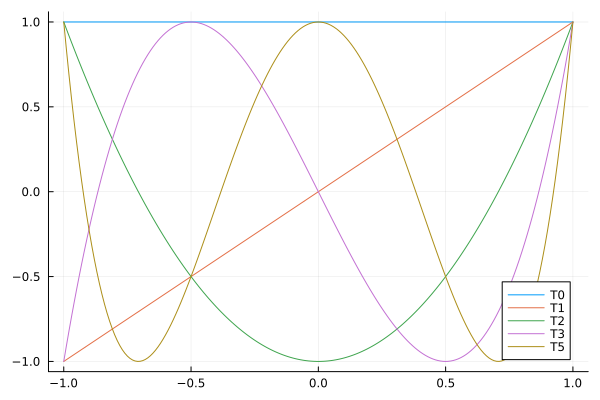

In [9]:
B5 = basis(5)
xr = -1:0.01:1
yr1 = [B5[1](t) for t in xr]
yr2 = [B5[2](t) for t in xr]
yr3 = [B5[3](t) for t in xr]
yr4 = [B5[4](t) for t in xr]
yr5 = [B5[5](t) for t in xr]
plot(xr,yr1,label="T0")
plot!(xr,yr2,label="T1")
plot!(xr,yr3,label="T2")
plot!(xr,yr4,label="T3")
plot!(xr,yr5,label="T5")

In [10]:
# savefig("chebyshevbasis5.png")

The verification of the orthogonality is defined by the function below.

In [11]:
"""
    function orthogonality(n::Int64)

Verifies the orthogonality of the Chebyshev basis
for the first n Chebyshev polynomials.
Prints the matrix of all inner products.
"""
function orthogonality(n::Int64)
    b = basis(n)
    for i=1:n
        for j=1:n
            ip = innerproduct(b[i],b[j])
            ipstr = @sprintf("%+.2e", ip)
            print(" $ipstr")
        end
        println("")
    end
end

orthogonality

In [12]:
orthogonality(5)

 +2.00e+00 +1.06e-16 -5.30e-17 +1.06e-16 -7.07e-17
 +1.06e-16 +1.00e+00 +1.59e-16 -8.83e-17 +2.65e-16
 -5.30e-17 +1.59e-16 +1.00e+00 +3.00e-16 -2.12e-16
 +1.06e-16 -8.83e-17 +3.00e-16 +1.00e+00 +3.71e-16
 -7.07e-17 +2.65e-16 -2.12e-16 +3.71e-16 +1.00e+00


We observe the identity matrix (modulo roundoff of machine precision), except for the first number in the first row and column, which equals ``2``.

### 2. Computing the Least Squares Approximation

For any function $f$ and the first $n+1$ Chebyshev polynomials $T_i$, $i=0,1,\ldots,n$, the polynomial approximation $p$ of degree $n$ is

$$
    p(x) = \frac{c_0}{2} + \sum_{i=0}^n c_i T_i,
$$

where the coefficients are the inner products of $f$ with the basis functions:

$$
    c_i = \langle f, T_i \rangle, \quad i=0,1,\ldots,n.
$$

The coefficients of the Chebyshev approximation are computed by the function below.

In [13]:
"""
    function coefficients(f::Function,b::Array{Function,1})

returns the inner products of f with the basis functions in b.
"""
function coefficients(f::Function,b::Array{Function,1})
    dim = length(b)
    result = zeros(dim)
    for i=1:dim
        result[i] = innerproduct(f,b[i])
    end
    return result
end

coefficients

With the coefficients and the array of basis functions, we can define the function for the approximant.

In [14]:
"""
    function approximation(c::Array{Float64,1},b::Array{Function,1})

Given in c are the coefficients of the Chebyshev approximation
with the basis functions in f.
Returns the approximation as a function.
"""
function approximation(c::Array{Float64,1},b::Array{Function,1})
    first(x) = c[1]*b[1](x)/2
    rest(x) = sum([c[k]*b[k](x) for k=2:length(c)])
    result(x) = first(x) + rest(x)
    return result
end

approximation

Let us compute the least squares approximation of $\exp(x)$ for $x \in [-1,1]$ of degree 3.

In [15]:
b3 = basis(3)
c3 = coefficients(exp, b3)

3-element Vector{Float64}:
 2.532131755504017
 1.1303182079849703
 0.27149533953407656

Observe that the coefficients are decreasing in magnitude.

In [16]:
a3 = approximation(c3,b3)

(::var"#result#approximation##4"{var"#rest#approximation##1"{Vector{Float64}, Vector{Function}}, var"#first#approximation##0"{Vector{Float64}, Vector{Function}}}) (generic function with 1 method)

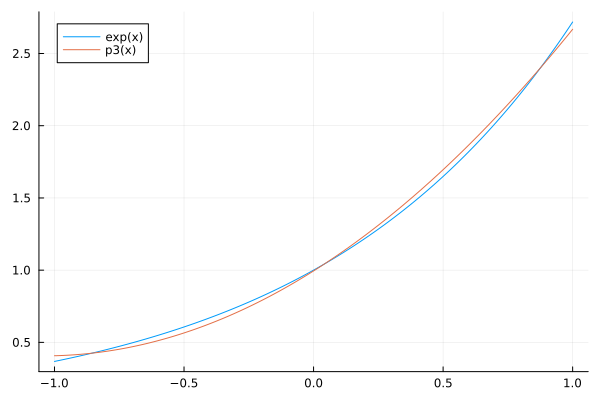

In [17]:
xr = -1.0:0.01:1.0
ex = [exp(t) for t in xr]
px = [a3(t) for t in xr]
plot(xr,ex,label="exp(x)",legend=:topleft)
plot!(xr,px,label="p3(x)")

In [18]:
# savefig("chebyshevapp3exp.png")

Let us make a plot of the error $|\exp(x) - p_3(x)|$ for $x \in [-1,+1]$.   

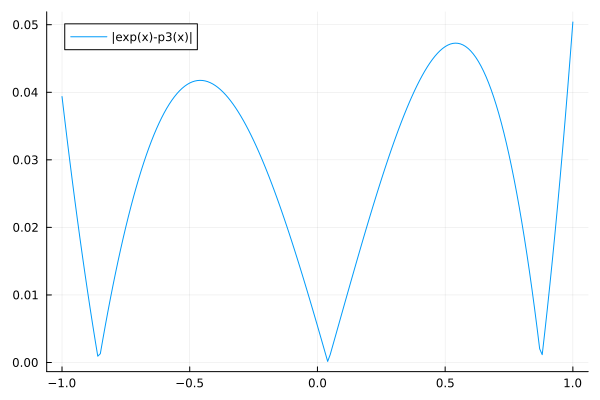

In [19]:
errors = [abs(exp(t) - a3(t)) for t in xr]
plot(xr, errors, label="|exp(x)-p3(x)|",legend=:topleft)

In [20]:
# savefig("chebysheverr3exp.png")